In [15]:
# First load some libraries, including History Matching
%load_ext autoreload
%autoreload 2

from pathlib import Path
import re
from tempfile import NamedTemporaryFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyDOE import lhs
import seaborn as sns
from wand.image import Image as WImage

from history_matching import HistoryMatching, HistoryMatchingCut, quick_read, Basis
from history_matching.examples.sir import SIR


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
WORK_DIR = Path.cwd().absolute()                # notebook version
# WORK_DIR = Path(__file__).parent.absolute()     # script version
print(f"Current working directory is '{WORK_DIR}'")
iteration = int(re.search(r'iter(\d+)', WORK_DIR.parts[-1]).group(1)) # Index of the current iteration
print(f"Current iteration is {iteration}")

Current working directory is '/home/clorton/src/hm-phylo-test/history_matching/history_matching/examples/Stochastic SIR/iter2'
Current iteration is 2


In [13]:
IMG_SAVE = True     # Set to `True` to temporarily save images to disk.

In [3]:
# Observed data
observations = pd.DataFrame({
    'Times': [3, 15],
    'Prevalence': [15, 40],
    'Stdev': [4, 2.3],
})
display(observations)

# For this first iteration, we're going to make one "cut" using the first observation, but 
# you can separately do multiple "cuts" per iteration using several obervations (separately)
# We'll need a name for this cut and the desired results
cut_name = 'Prevalence_Meas' # No spaces or strange characters!

desired_result_idx = 1 # Second time point
desired_result = observations.iloc[desired_result_idx]['Prevalence']
desired_result_var = observations.iloc[desired_result_idx]['Stdev']**2

,Times,Prevalence,Stdev
0,3,15,4.0
1,15,40,2.3


In [4]:
# Here we define the parameter names and ranges
param_info = pd.DataFrame({
    'Name':['Beta', 'Gamma'],
    'Min':[1e-6, 1e-6],
    'Max':[0.01, 0.5]
}).set_index('Name')
params = param_info.index.values
n_params = param_info.shape[0] # We'll use this one place later
display(param_info)

,Min,Max
Name,,
Beta,0.000001,0.01
Gamma,0.000001,0.50


Displaying image in '/tmp/tmpvi9easy1'...


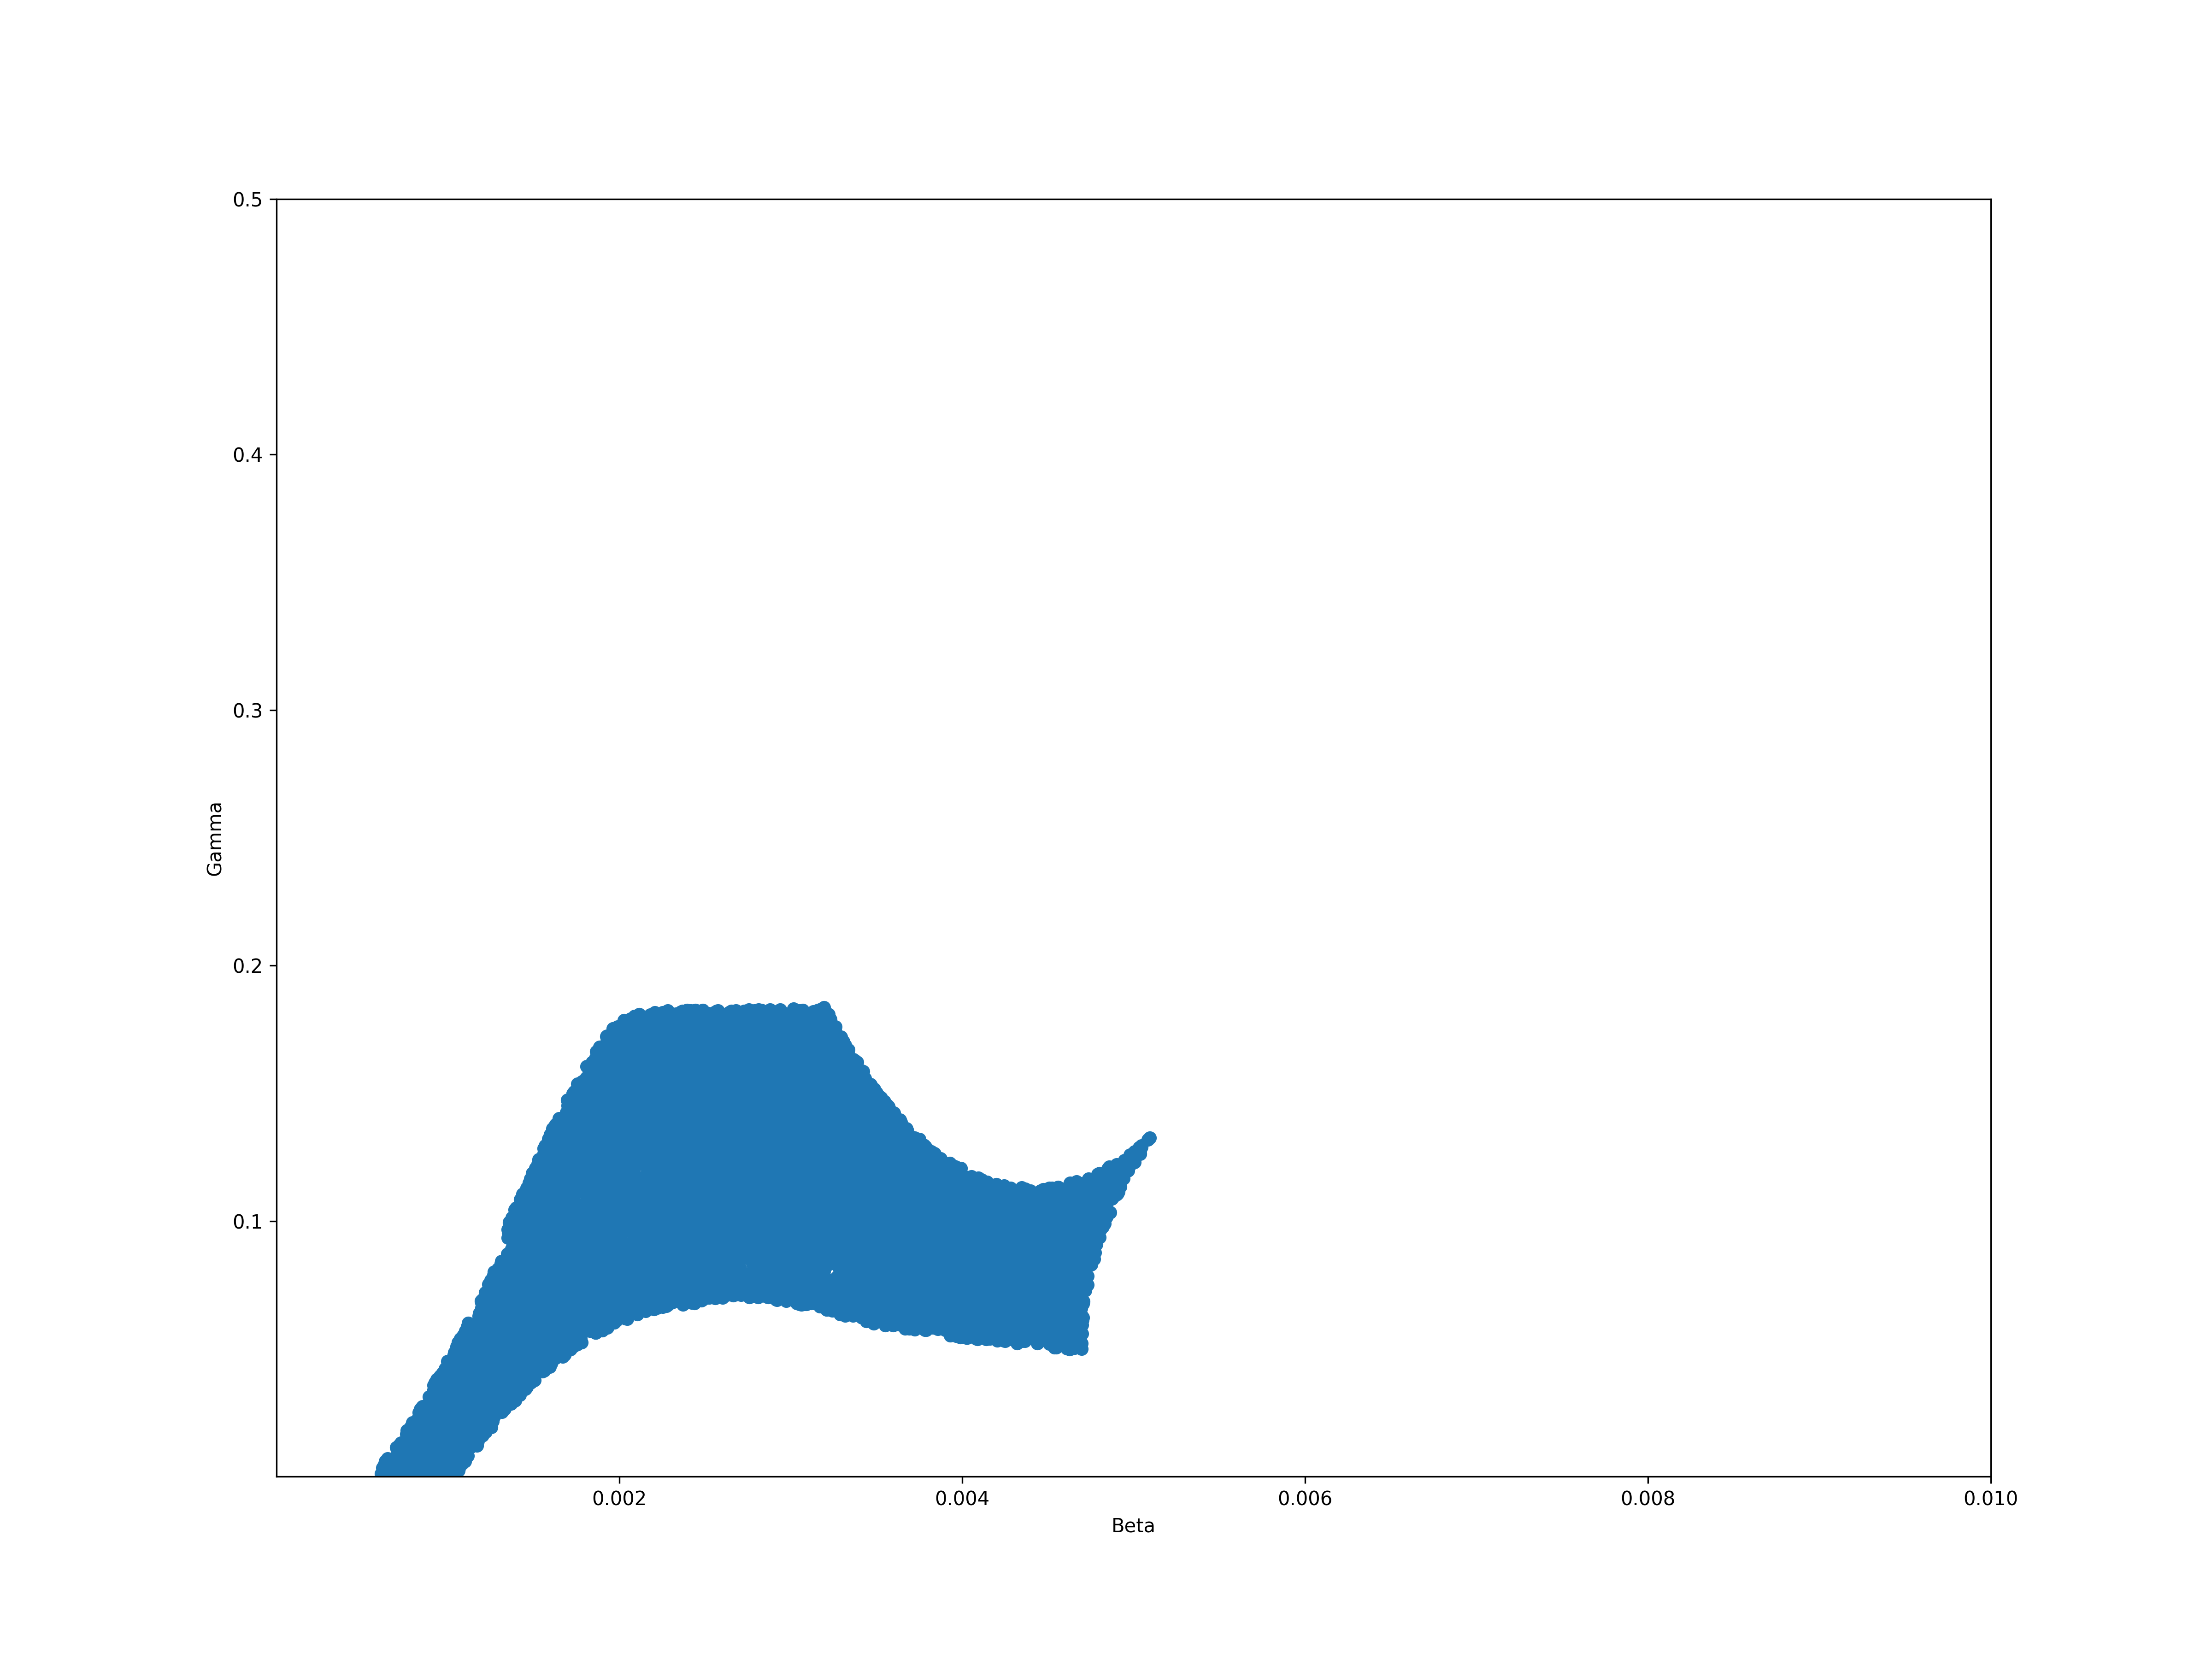

In [20]:
# Samples for the next iteration are saved to file, in this case it's "Candidates_for_iter1.csv"
# Just to see what they look like, we'll read that file and plot the samples
# Notice how the entire bottom right of the paramter space is empty?  Those points were rejected!

samples = pd.read_csv(f"Candidates_for_iter{iteration+1}.csv")

fig, ax = plt.subplots(figsize=(16,12), dpi=300)
ax.scatter(x=samples[param_info.index.values[0]], y=samples[param_info.index.values[1]])
ax.set_xlim([param_info['Min'][0], param_info['Max'][0]])
ax.set_ylim([param_info['Min'][1], param_info['Max'][1]])
ax.set_xlabel(param_info.index.values[0])
ax.set_ylabel(param_info.index.values[1])

if IMG_SAVE:
    tmp = NamedTemporaryFile(delete=False)
    tmp.close()
    fig.savefig(Path(tmp.name), format="png")
    img = WImage(filename=Path(tmp.name))
    print(f"Displaying image in '{tmp.name}'...")
    display(img)
    Path(tmp.name).unlink()


Displaying image in '/tmp/tmpb1tmt97l'...


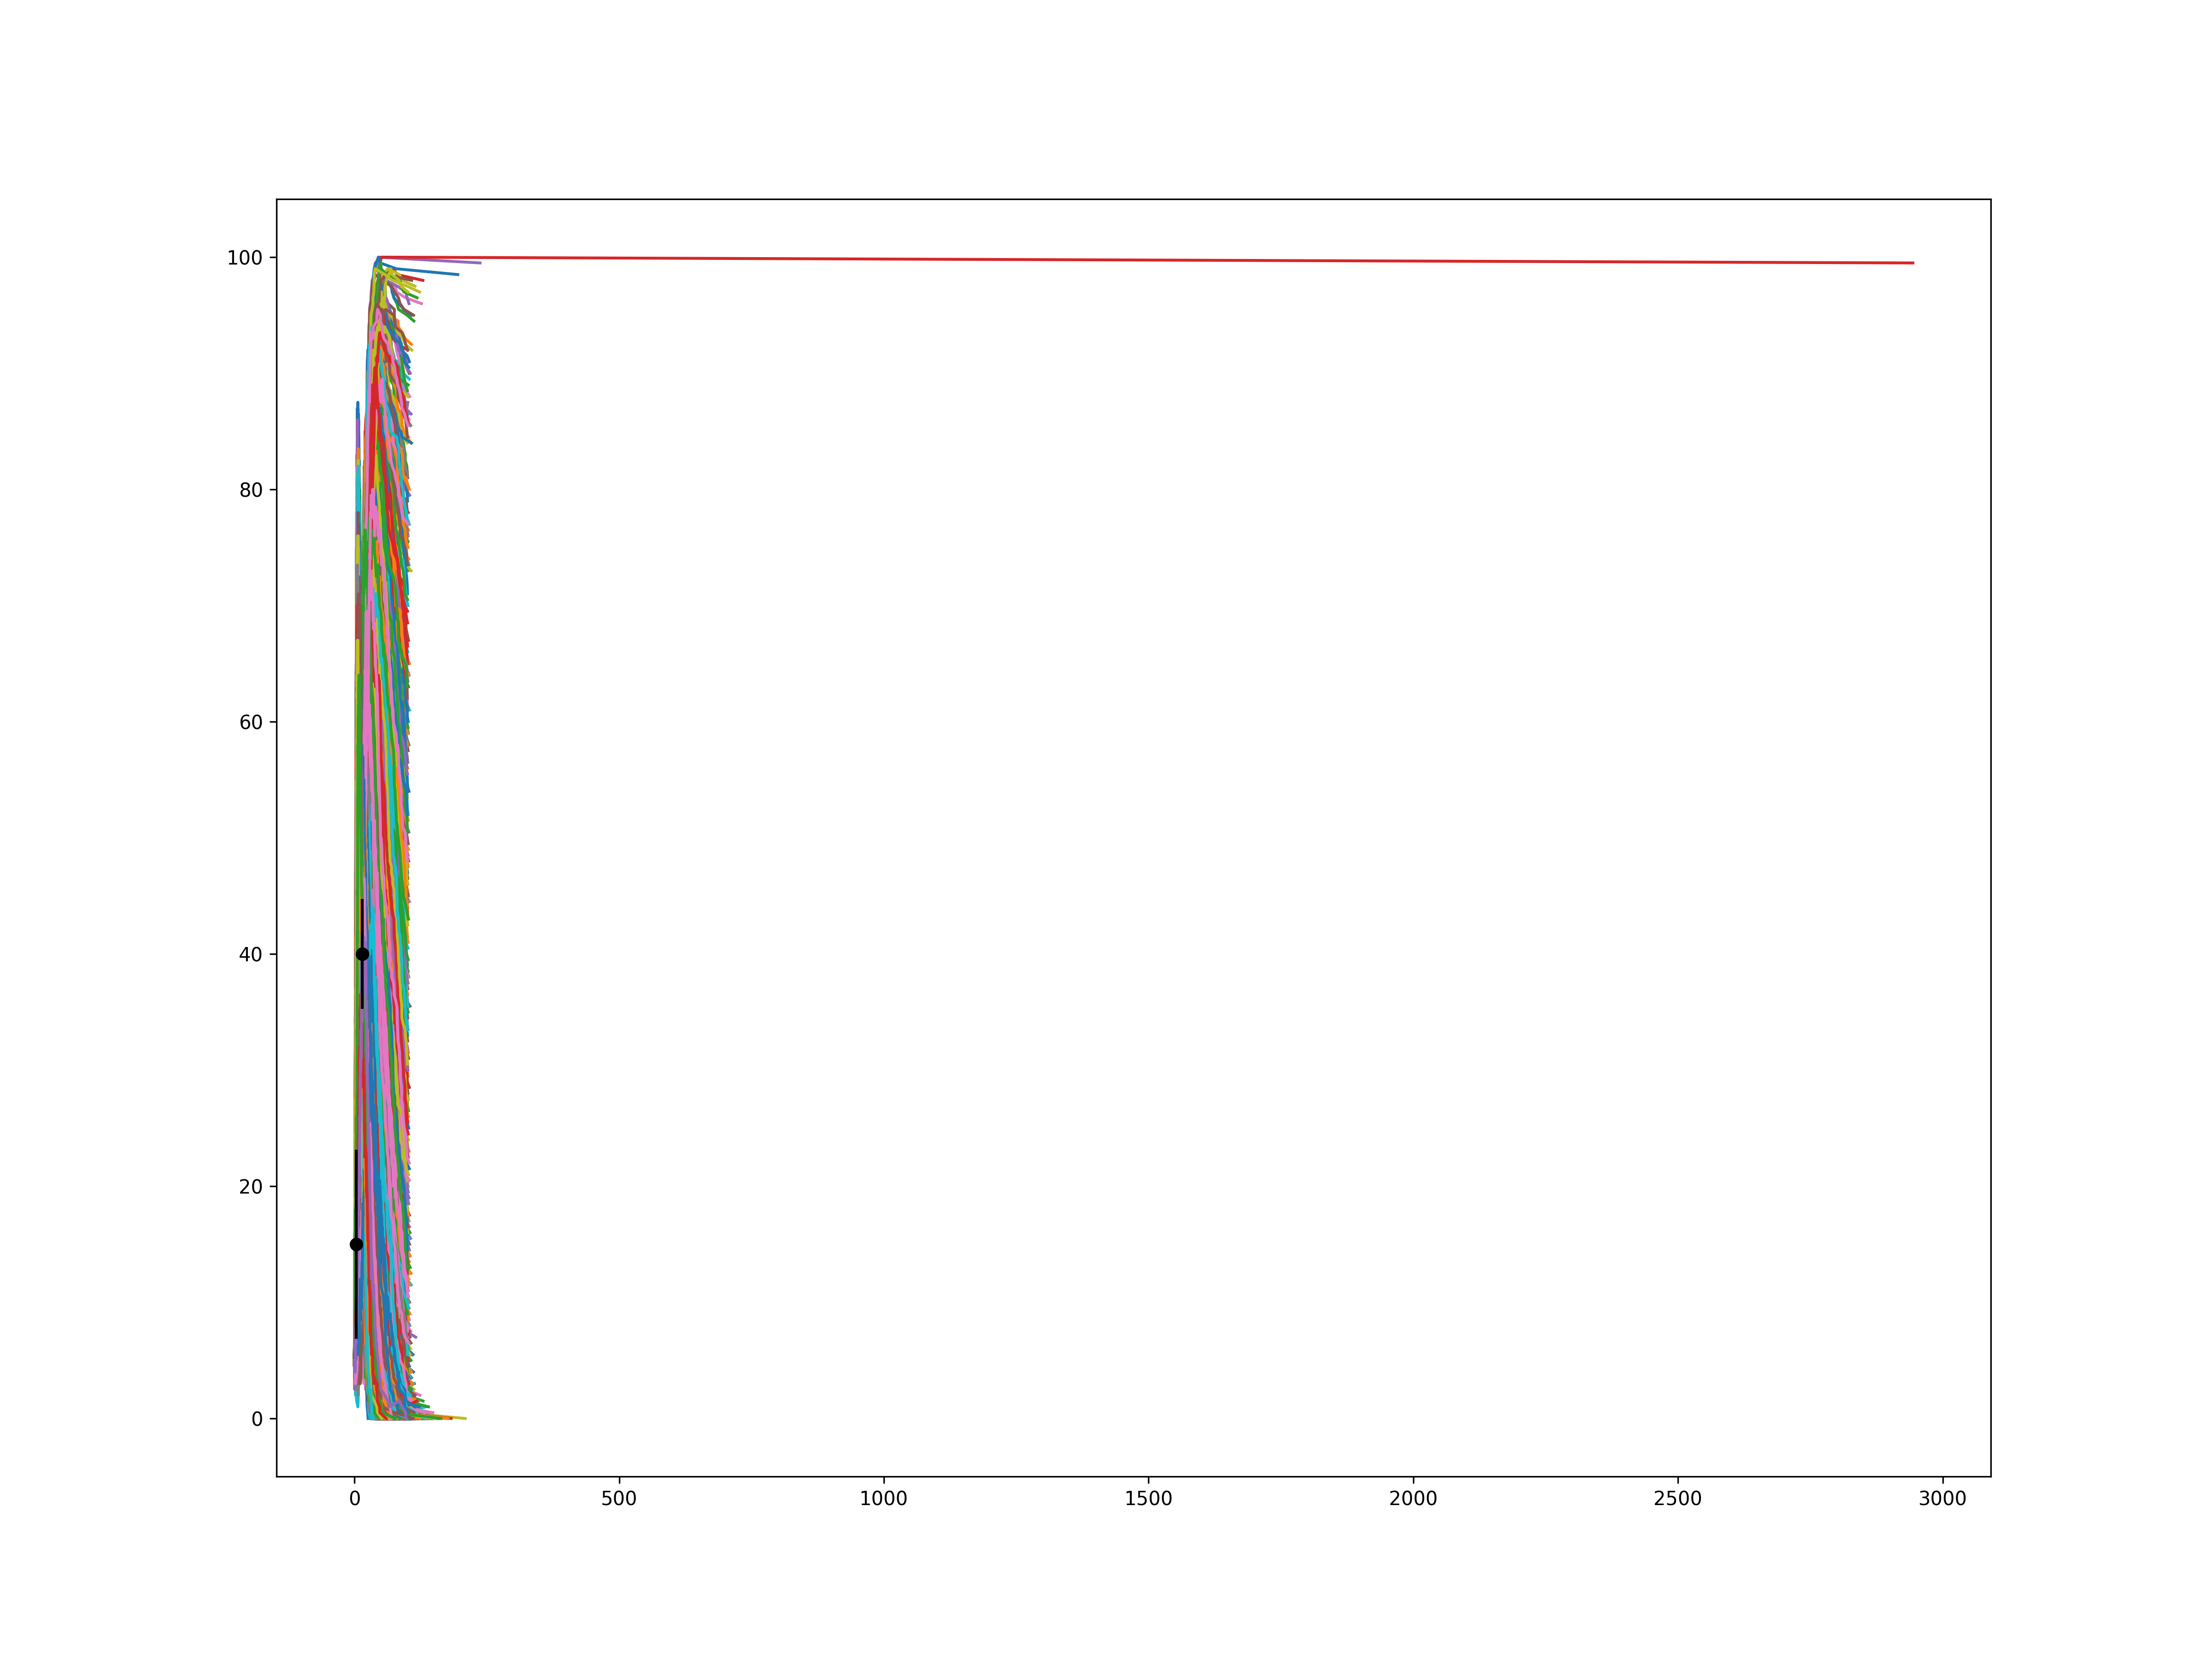

In [21]:
# Run the simulations specified by the samples and plot the results

fig = plt.figure(figsize=(16,12), dpi=300)
sim_results = []

samples['Seed'] = np.random.randint(0, 1e6, samples.shape[0])

for idx, sample in samples.iterrows():
    z = SIR(beta=sample['Beta'], gamma=sample['Gamma'], seed=sample['Seed'])
    T,_,P = z.sim() # Run the simulation
    prevalence = [p[1] for p in P] # Analyze the simulation to get the prevalence
    
    # Because we used SSA, the time vector T does not contain the prevalence at the 
    # exact observation time, t_obs.  Let's find the first measurement after t_obs
    # Here I'm getting both observations, but we really only need one
    for i, t_obs in enumerate(observations['Times']):
        value = next((p[1] for t,p in zip(T,P) if t>t_obs), None)
        if not value:
            value = P[-1][1]
        sim_results.append([idx, i, t_obs, value])
    
    # Plot
    plt.plot(T,prevalence)

# Convert sim_results into a pandas DataFrame
sim_results = pd.DataFrame(sim_results, columns=['Sample_Id', 'ObsIdx', 'ObsTime', 'Prevalence'])

# Simulation results will ultimately need a 'Sample_Id' and 'Sim_Id'
# The Sample_Id corresponds to the index in the samples dataframe above
# You can do more than one replicate of each sample, in which case you'd
# end up wiht more than one Sim_Id per Sample_Id.  We're not doing that here,
# so we can basically set Sim_Id to anything.
sim_results['Sim_Id'] = sim_results['Sample_Id']
    
# Plot the observations over the realized trajectories
for i,obs in observations.iterrows():
    plt.plot(obs['Times'], obs['Prevalence'], 'ko')
    plt.plot(
        [obs['Times'],obs['Times']], 
        [obs['Prevalence']-2*obs['Stdev'],obs['Prevalence']+2*obs['Stdev']],
        'k-')

if IMG_SAVE:
    tmp = NamedTemporaryFile(delete=False)
    tmp.close()
    fig.savefig(Path(tmp.name), format="png")
    img = WImage(filename=Path(tmp.name))
    print(f"Displaying image in '{tmp.name}'...")
    display(img)
    Path(tmp.name).unlink()


In [22]:
def calc_goodness(sm):
    err2 = (sm['Prevalence'].values - observations['Prevalence'][sm['ObsIdx']].values)**2 / observations['Stdev'][sm['ObsIdx']].values**2
    return np.sqrt(np.sum(err2))

goodness = sim_results.groupby('Sample_Id').apply(calc_goodness)
display(goodness.head())

Sample_Id
0    5.058367
1    6.103278
2    0.652174
3    9.646891
4    7.243275
dtype: float64

Kept 1604 parameter configurations
Displaying image in '/tmp/tmp_fbp_a6i'...


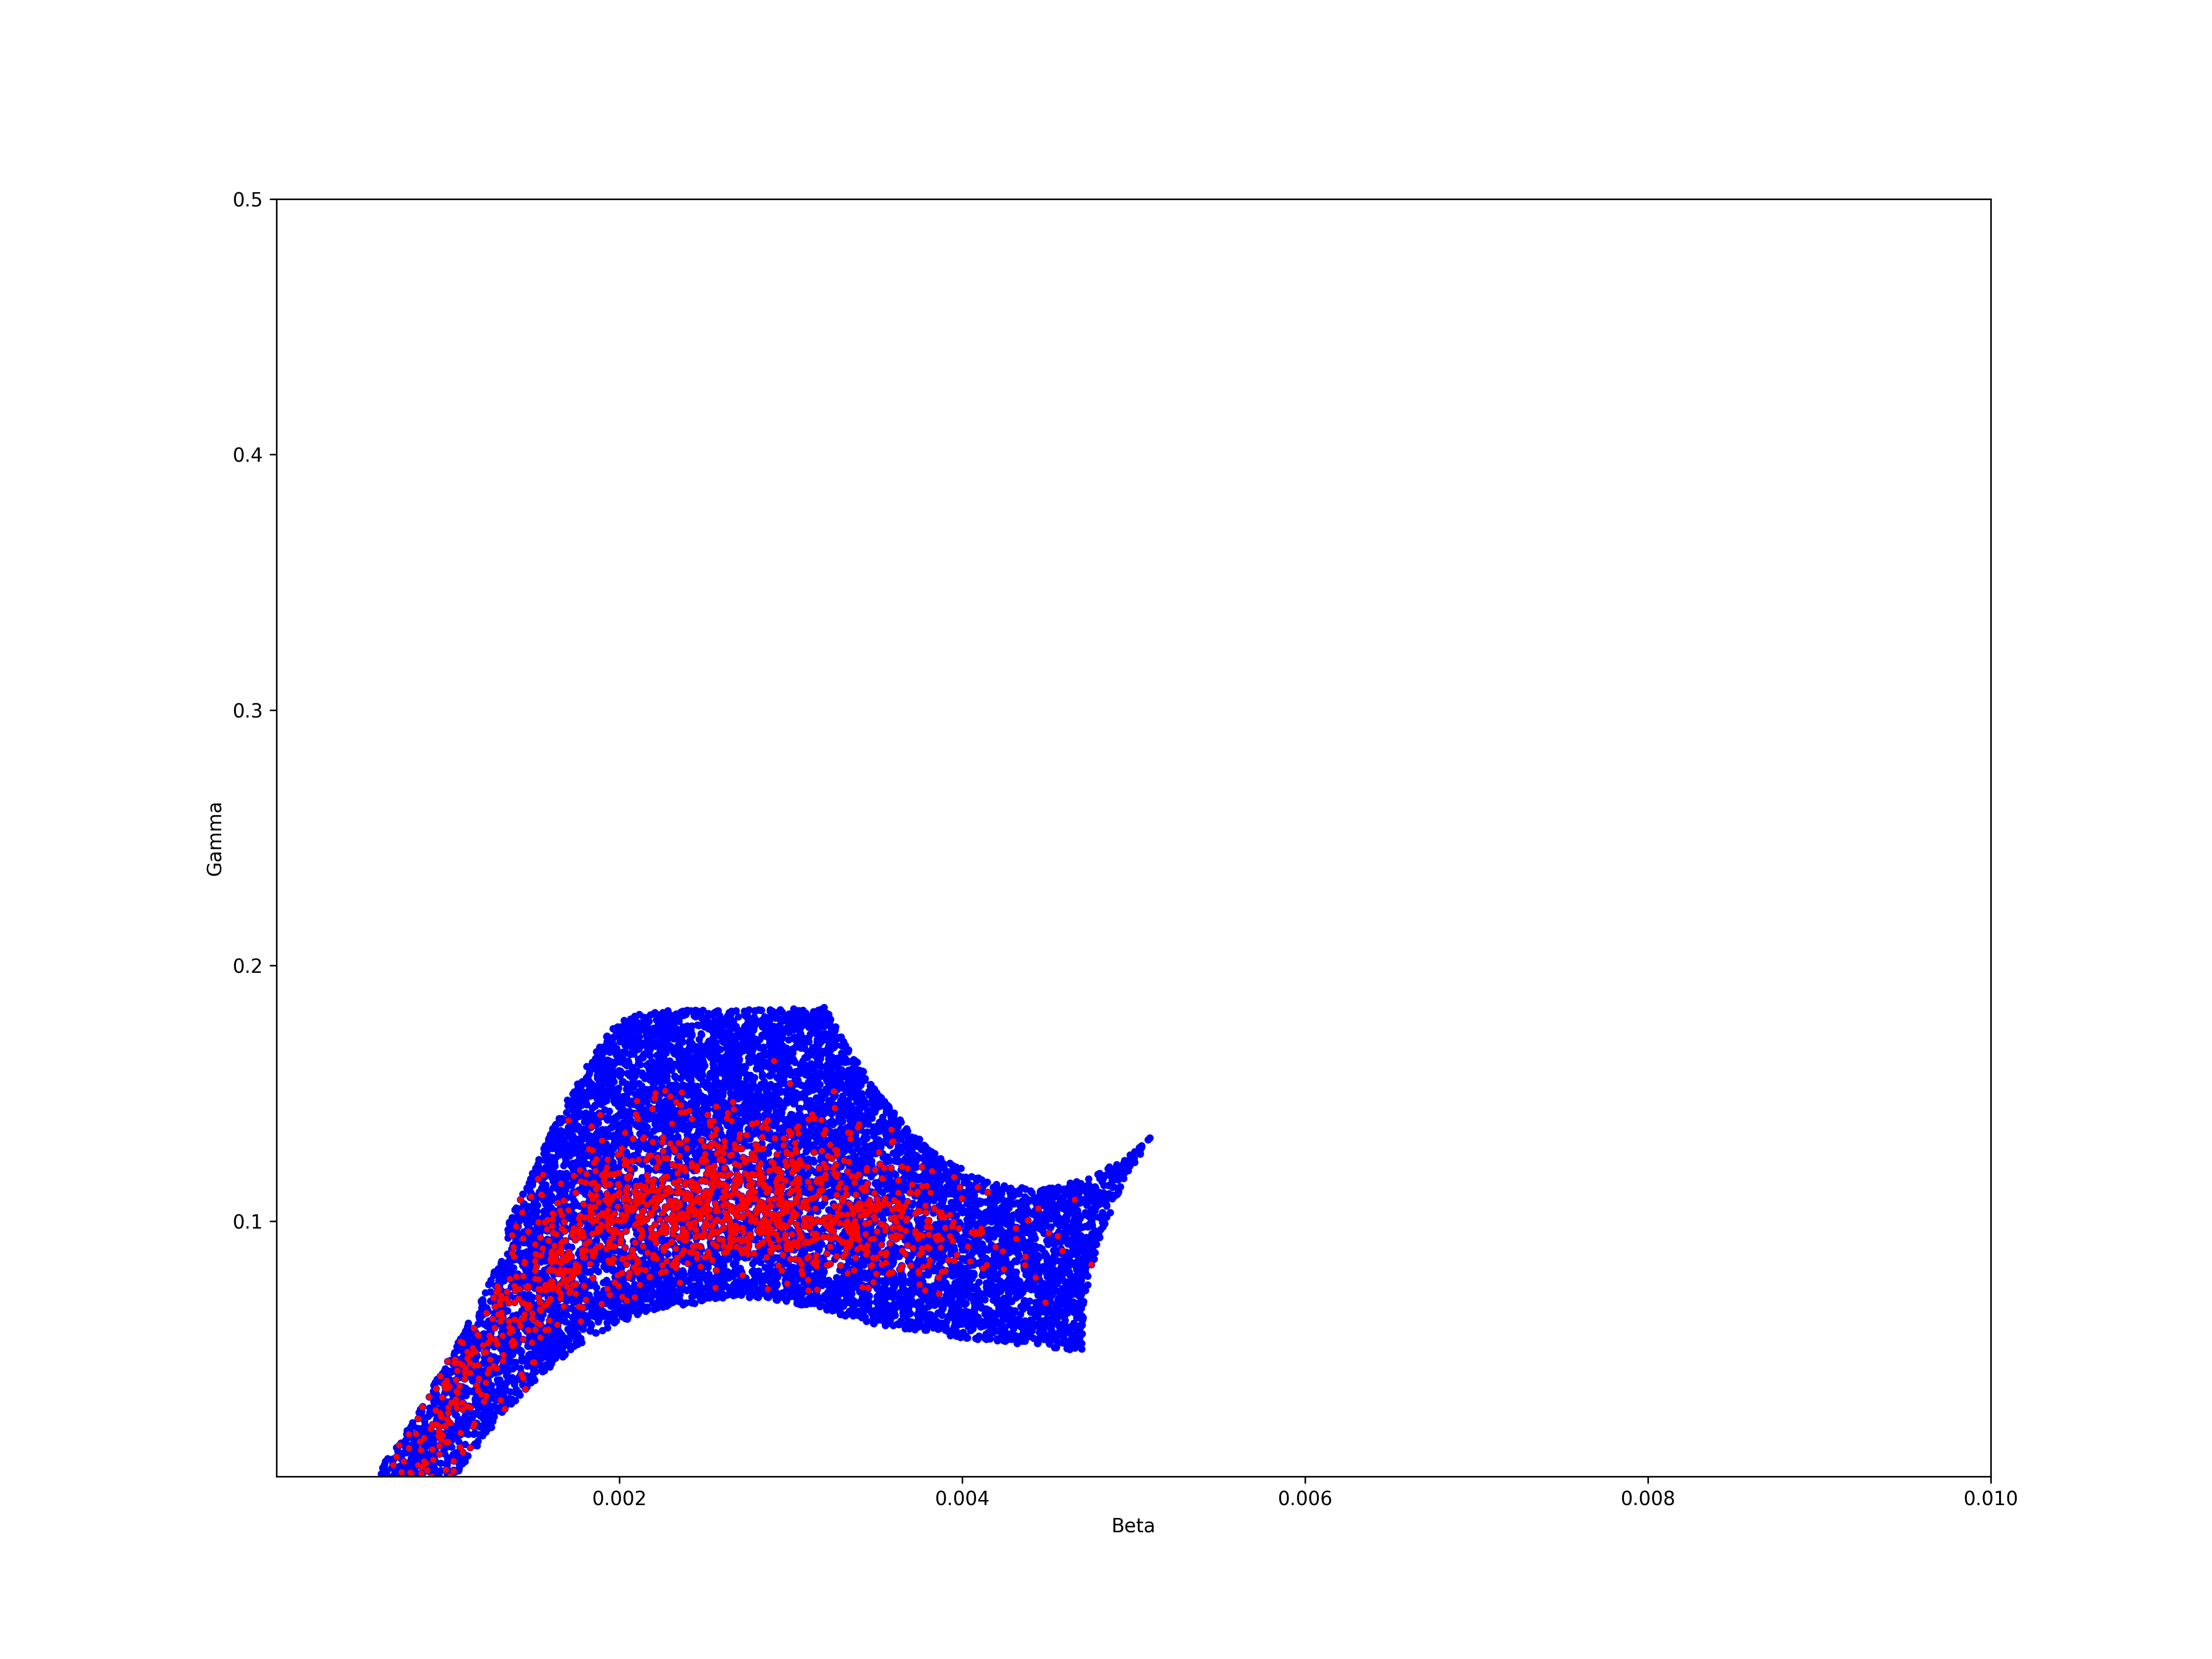

In [23]:
#keep_inds = goodness.sort_values(ascending=True).head(100).index
keep_inds = goodness[goodness < 2].index
print('Kept %d parameter configurations'%keep_inds.shape[0])

fig, ax = plt.subplots(figsize=(16,12), dpi=300)
ax.scatter(x=samples[param_info.index.values[0]], y=samples[param_info.index.values[1]], color='b', s=8)
ax.scatter(x=samples.loc[keep_inds, param_info.index.values[0]], y=samples.loc[keep_inds, param_info.index.values[1]], color='r', s=5)

ax.set_xlim([param_info['Min'][0], param_info['Max'][0]])
ax.set_ylim([param_info['Min'][1], param_info['Max'][1]])
ax.set_xlabel(param_info.index.values[0])
ax.set_ylabel(param_info.index.values[1])

if IMG_SAVE:
    tmp = NamedTemporaryFile(delete=False)
    tmp.close()
    fig.savefig(Path(tmp.name), format="png")
    img = WImage(filename=Path(tmp.name))
    print(f"Displaying image in '{tmp.name}'...")
    display(img)
    Path(tmp.name).unlink()


Displaying image in '/tmp/tmpahbqkm10'...


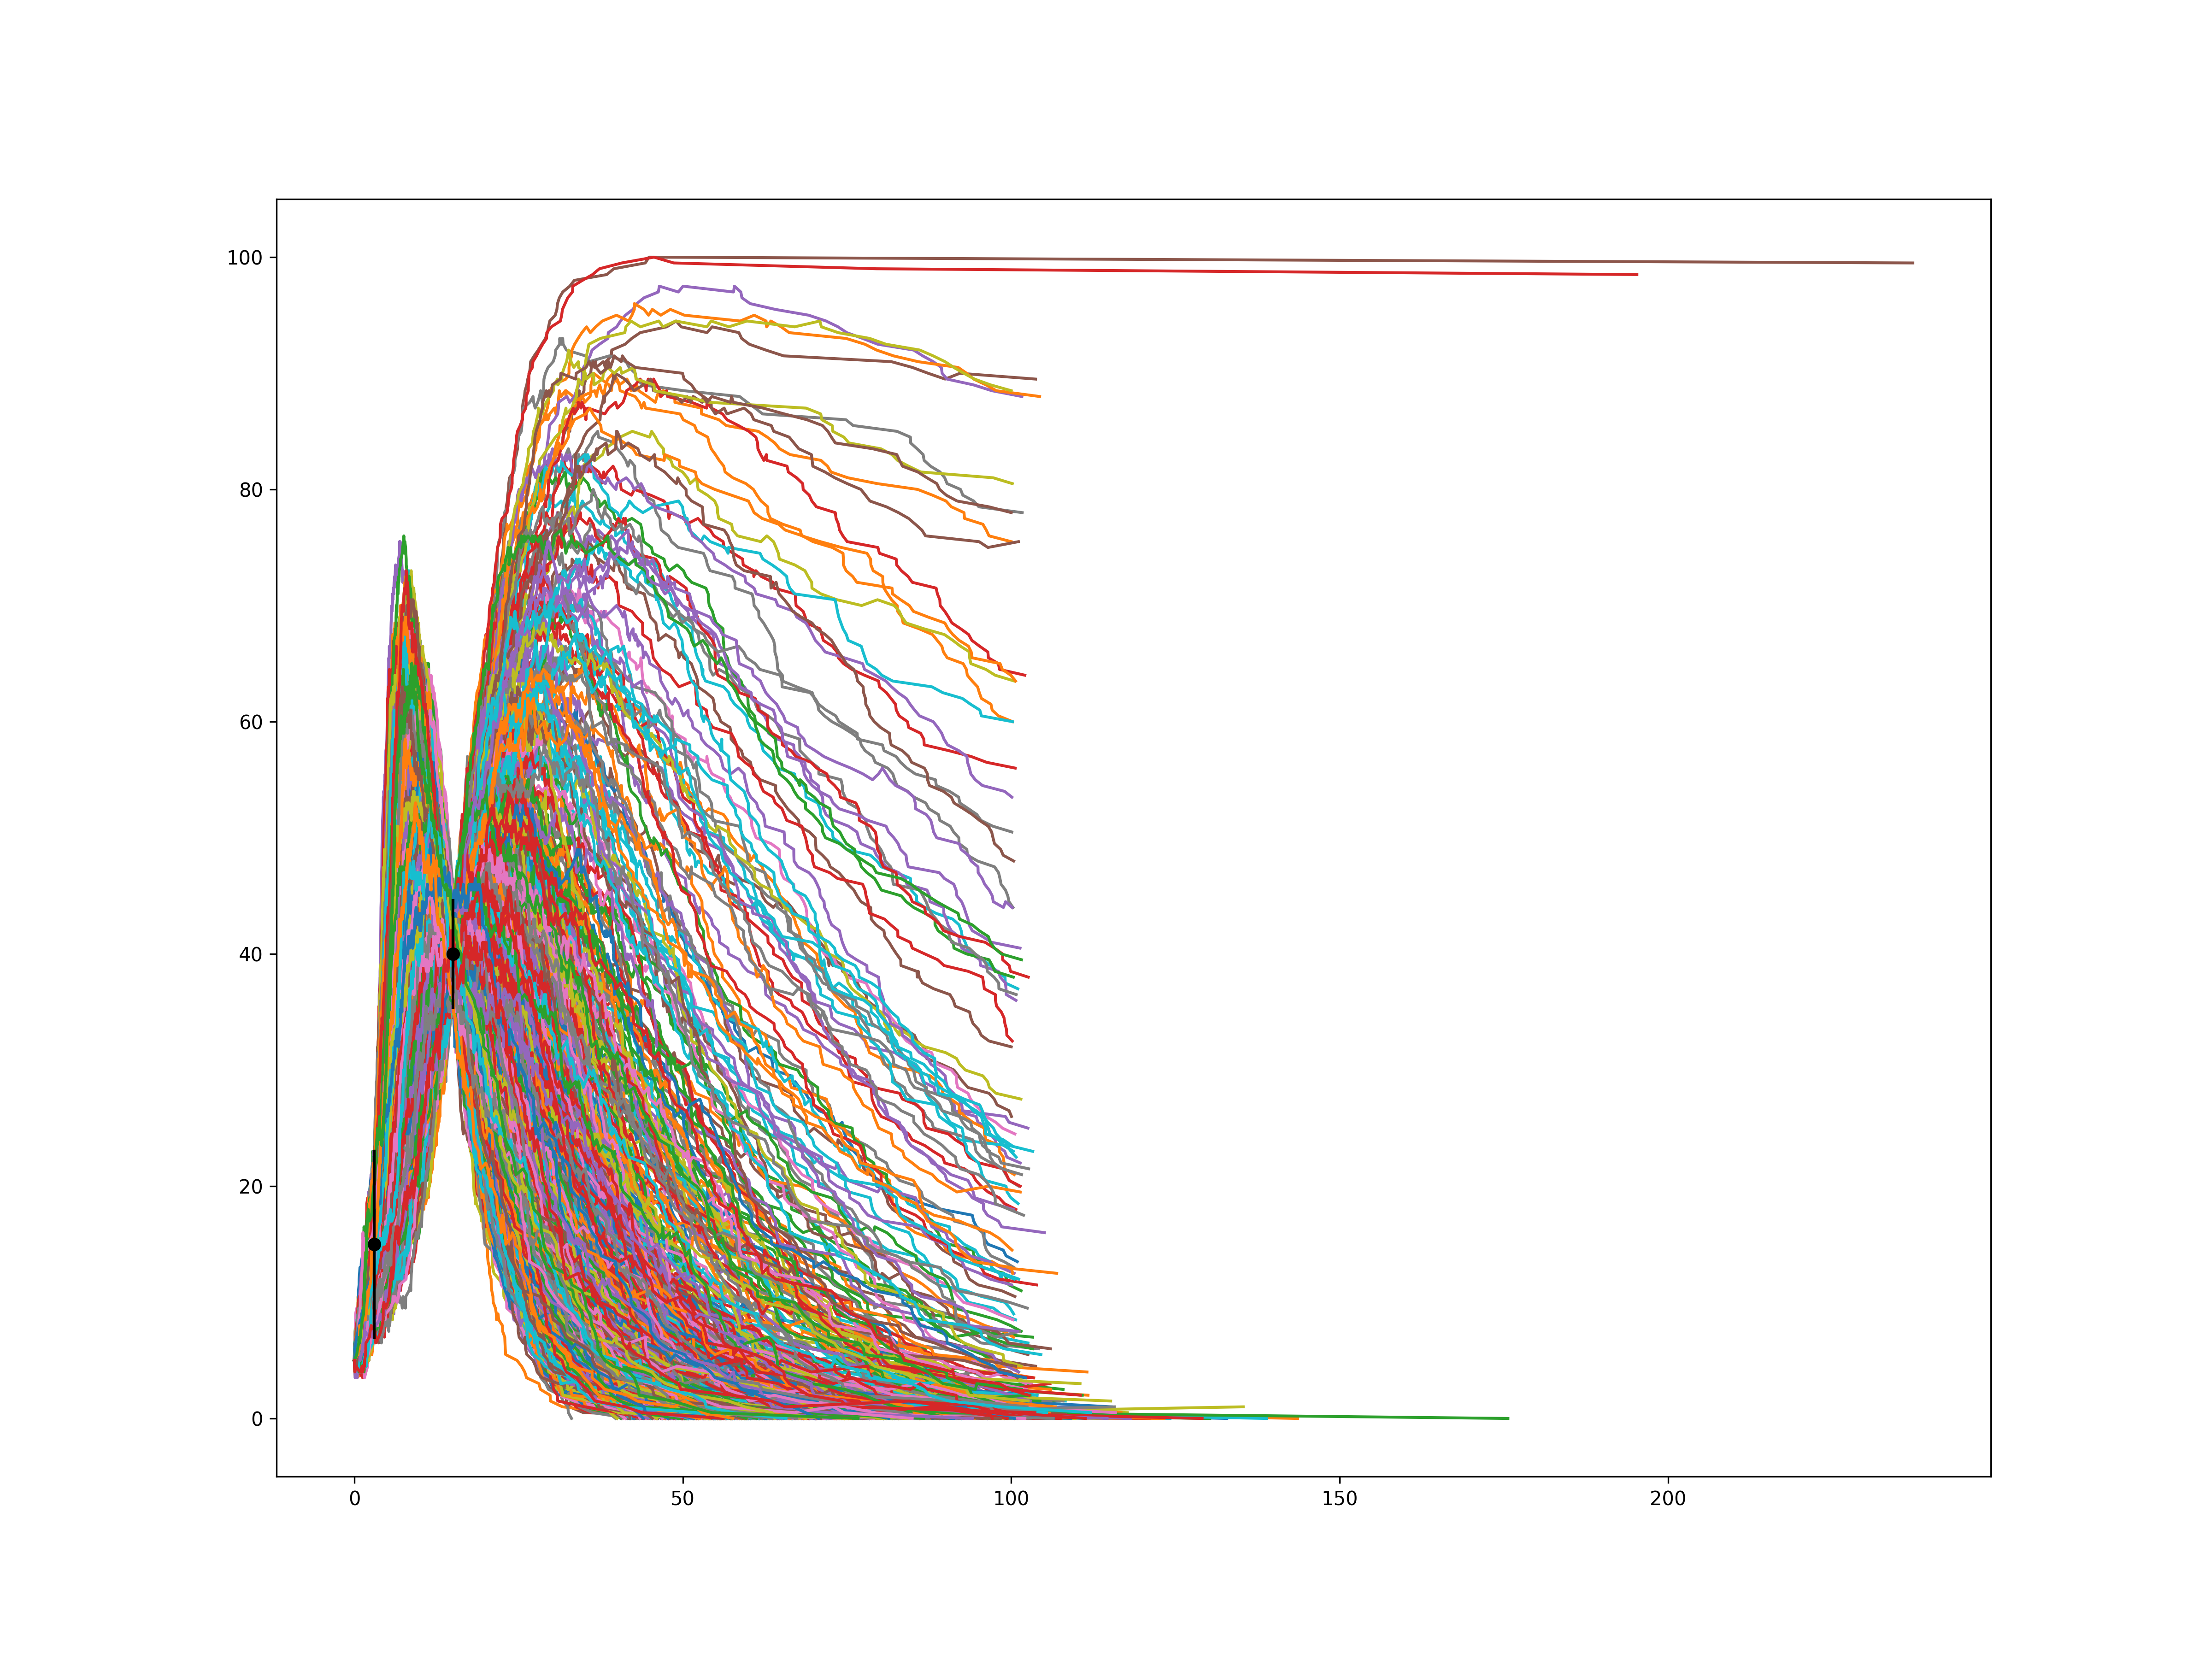

In [24]:
# Run the simulations specified by the samples and plot the results

fig = plt.figure(figsize=(16,12), dpi=300)
sim_results = []

samples_keep = samples.iloc[keep_inds]

for idx, sample in samples_keep.iterrows():
    z = SIR(beta=sample['Beta'], gamma=sample['Gamma'], seed=sample['Seed'])
    T,_,P = z.sim() # Run the simulation
    prevalence = [p[1] for p in P] # Analyze the simulation to get the prevalence
    
    # Because we used SSA, the time vector T does not contain the prevalence at the 
    # exact observation time, t_obs.  Let's find the first measurement after t_obs
    # Here I'm getting both observations, but we really only need one
    for i, t_obs in enumerate(observations['Times']):
        value = next((p[1] for t,p in zip(T,P) if t>t_obs), None)
        if not value:
            value = P[-1][1]
        sim_results.append([idx, i, t_obs, value])
    
    # Plot
    plt.plot(T,prevalence)

# Convert sim_results into a pandas DataFrame
sim_results = pd.DataFrame(sim_results, columns=['Sample_Id', 'ObsIdx', 'ObsTime', 'Prevalence'])

# Simulation results will ultimately need a 'Sample_Id' and 'Sim_Id'
# The Sample_Id corresponds to the index in the samples dataframe above
# You can do more than one replicate of each sample, in which case you'd
# end up wiht more than one Sim_Id per Sample_Id.  We're not doing that here,
# so we can basically set Sim_Id to anything.
sim_results['Sim_Id'] = sim_results['Sample_Id']
    
# Plot the observations over the realized trajectories
for i,obs in observations.iterrows():
    plt.plot(obs['Times'], obs['Prevalence'], 'ko')
    plt.plot(
        [obs['Times'],obs['Times']], 
        [obs['Prevalence']-2*obs['Stdev'],obs['Prevalence']+2*obs['Stdev']],
        'k-')

if IMG_SAVE:
    tmp = NamedTemporaryFile(delete=False)
    tmp.close()
    fig.savefig(Path(tmp.name), format="png")
    img = WImage(filename=Path(tmp.name))
    print(f"Displaying image in '{tmp.name}'...")
    display(img)
    Path(tmp.name).unlink()


/home/clorton/src/hm-phylo-test/.phylo/lib/python3.8/site-packages/seaborn/distributions.py:1718: UserWarning: `shade_lowest` is now deprecated in favor of `thresh`. Setting `thresh=0`, but please update your code.
  warnings.warn(msg, UserWarning)


Displaying image in '/tmp/tmp6ijl4nk7'...


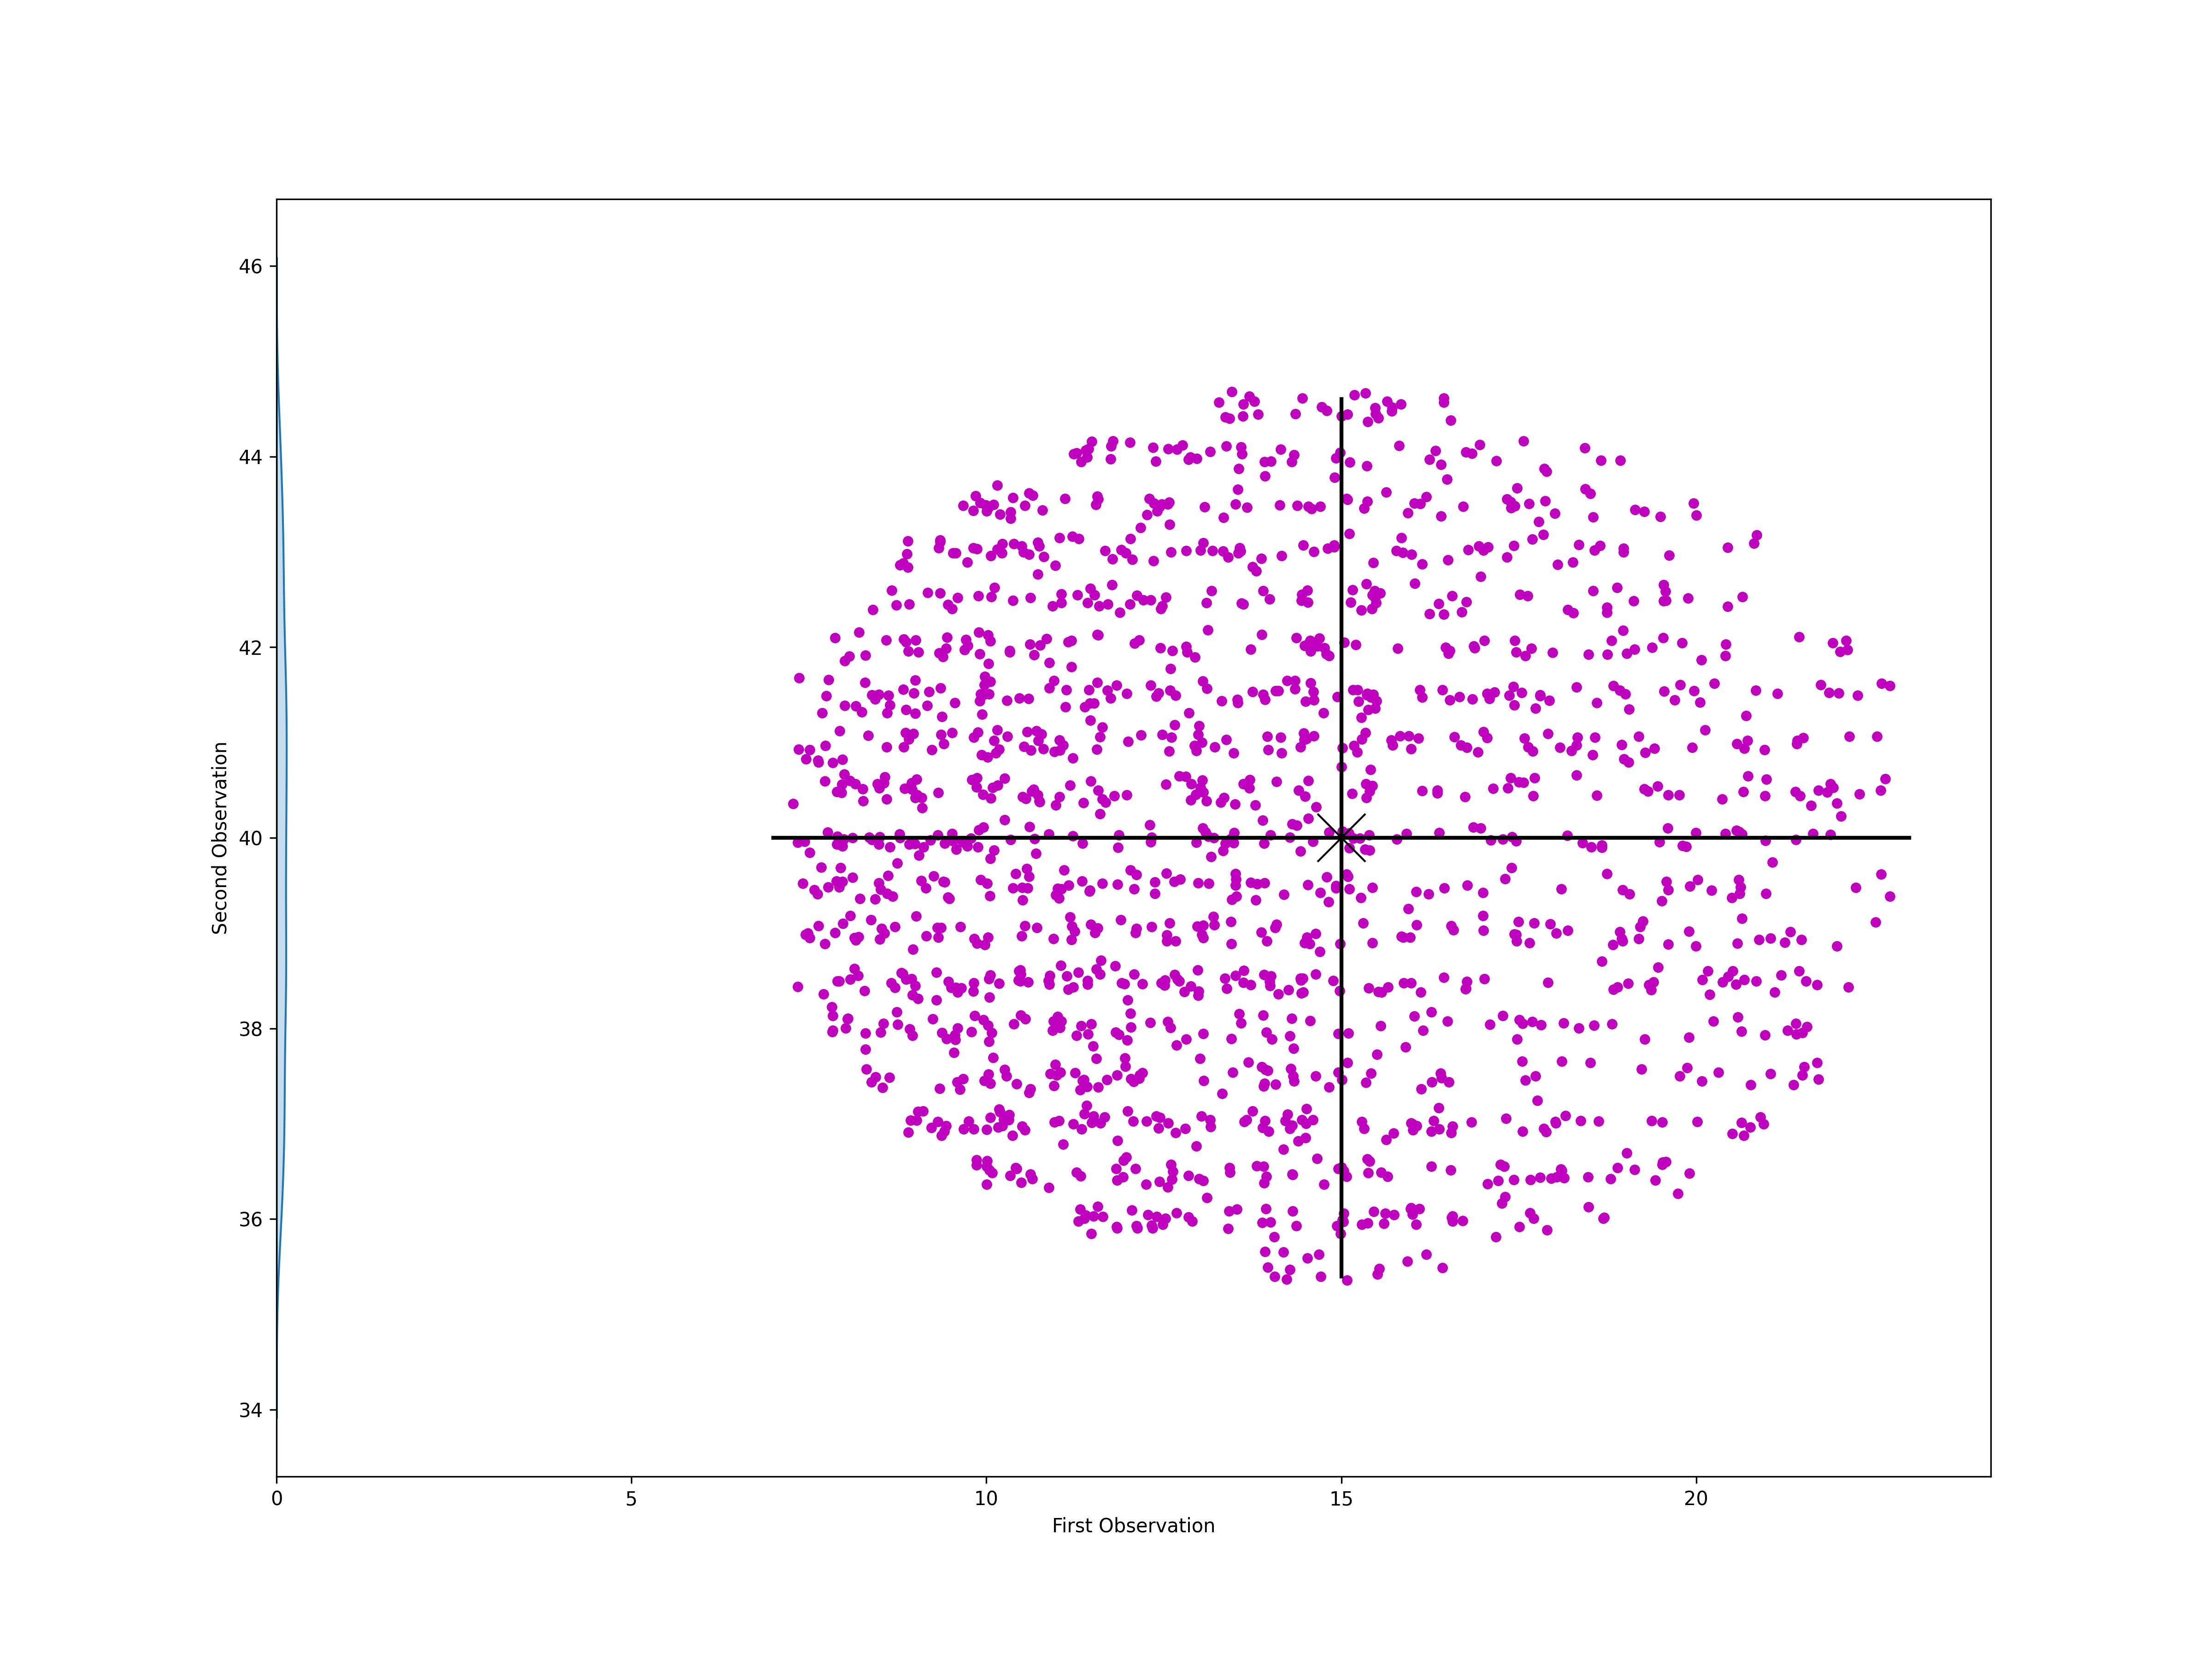

In [25]:
fig, ax = plt.subplots(figsize=(16,12), dpi=300)

prev = sim_results.pivot('Sample_Id', 'ObsIdx', 'Prevalence')

def rand_jitter(arr):
    stdev = .01*(max(arr)-min(arr))
    return arr + np.random.randn(len(arr)) * stdev

sns.kdeplot(data=prev[0], y=prev[1], cmap="Blues", shade=True, shade_lowest=True, ax=ax)
ax.scatter(rand_jitter(prev[0]), rand_jitter(prev[1]), 20, marker='o', color='m')
ax.plot(observations['Prevalence'][0], observations['Prevalence'][1], 'kx', ms=25, lw=3)
ax.plot(
    [observations['Prevalence'][0] - 2*observations['Stdev'][0], 
     observations['Prevalence'][0] + 2*observations['Stdev'][0]],
    [observations['Prevalence'][1], observations['Prevalence'][1]],
    'k-', lw=2)
ax.plot(
    [observations['Prevalence'][0], observations['Prevalence'][0]],
    [observations['Prevalence'][1] - 2*observations['Stdev'][1], 
     observations['Prevalence'][1] + 2*observations['Stdev'][1]],
    'k-', lw=2)
ax.set_xlabel('First Observation')
ax.set_ylabel('Second Observation')

if IMG_SAVE:
    tmp = NamedTemporaryFile(delete=False)
    tmp.close()
    fig.savefig(Path(tmp.name), format="png")
    img = WImage(filename=Path(tmp.name))
    print(f"Displaying image in '{tmp.name}'...")
    display(img)
    Path(tmp.name).unlink()
else:
    plt.show()